# Assignment - Image Recognition (30 ⭕️s)

**Jonah Ebent**

## Overview

In this assignment you will train neural networks to recognize handwritten digits from the **MNIST** dataset.

You will:
- Train a *simple* neural network that flattens the 28×28 images into 1D arrays before feeding them into fully-connected (Dense) layers.
- Study the training behavior with **learning curves** and **confusion matrices** (in a blue color scheme).
- Produce **normalized confusion matrices** and interpret them.
- Experiment with different **learning rates**, **batch sizes**, and **numbers of epochs**.
- Implement a second model based on **Convolutional Neural Networks (CNNs)** and compare it against the flat-input network.

The running theme of the assignment is: *what does "good training" even mean, and how do we justify it with plots?*

### Notation

| Symbol | Description | Python |
|--------|-------------|--------|
| $X$ | Input images (28×28 matrices, values in [0,1]) | `x_train`, `x_test` |
| $y$ | Integer labels 0–9 | `y_train`, `y_test` |
| $\hat{y}$ | Model prediction (argmax of softmax) | `y_pred` |
| $\alpha$ | Learning rate | `learning_rate` |
| $B$ | Batch size | `batch_size` |
| $E$ | Number of epochs | `epochs` |
| $L$ | Loss (Sparse Categorical Crossentropy) | `loss` |
| $\text{Acc}$ | Classification accuracy | `accuracy` |

## Example Code. Setting up MNIST and a Flat-Input Neural Network

Run the following cells. They:
1. Import the libraries we need (TensorFlow/Keras, NumPy, Matplotlib, scikit-learn).
2. Load the MNIST dataset and normalize pixel values to [0, 1].
3. Visualize a few training examples.
4. Build a small fully-connected network that **flattens** each 28×28 image into a 784-long vector.
5. Train the model and plot the learning curves.
6. Produce a raw confusion matrix in a blue color scheme.

You will extend this code in the tasks that follow.

In [1]:
# TensorFlow/Keras for the model, NumPy for arrays, Matplotlib for plots
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn has handy confusion-matrix utilities
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#%matplotlib inline
#plt.style.use('ggplot')

# Fix a seed so results are reproducible (ish)
np.random.seed(42)
tf.random.set_seed(42)

### Load and inspect MNIST

MNIST is built into Keras. Each image is a 28×28 grayscale matrix with pixel values in [0, 255].

We normalize to [0, 1] so gradient descent has a better-conditioned input.

We save a fraction in a test dataset for later (the training never sees this)

In [2]:
# Load the dataset: 60k training images, 10k test images
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel intensities from [0, 255] to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test  shape: {x_test.shape},  y_test  shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28), y_train shape: (60000,)
x_test  shape: (10000, 28, 28),  y_test  shape: (10000,)


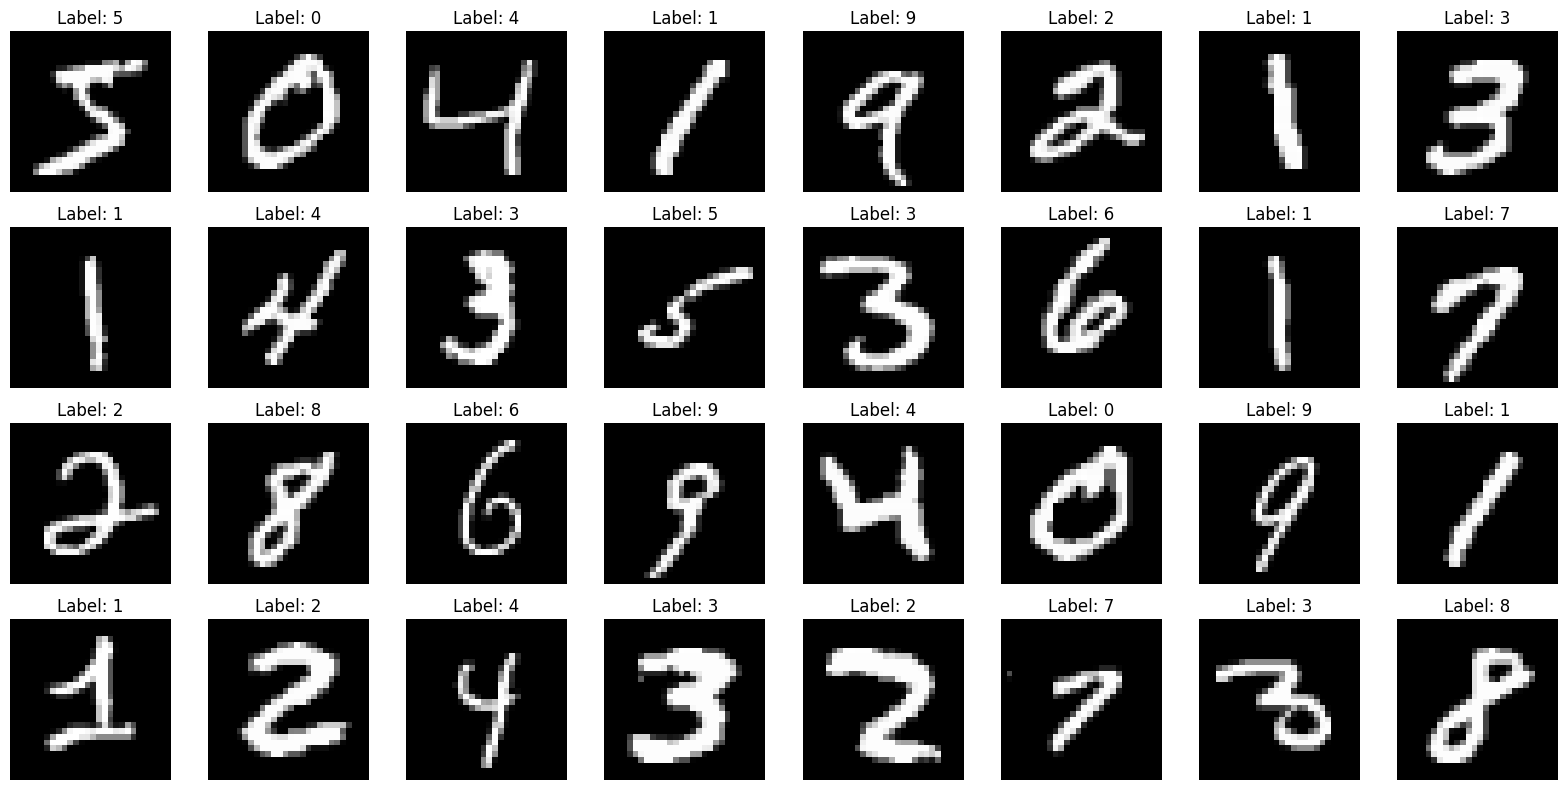

In [3]:
# Plot a grid of training images together with their labels.
# This is just to sanity-check what the data looks like.
height, width = 4, 8
fig, ax = plt.subplots(height, width, figsize=(2*width, 2*height))
for i in range(width * height):
    ax[i // width, i % width].imshow(x_train[i], cmap='gray')
    ax[i // width, i % width].set_title(f'Label: {y_train[i]}')
    ax[i // width, i % width].set_axis_off()
plt.tight_layout()
plt.show()

### Build a Flat-Input Neural Network

This model is deliberately **simple** (and not great). It:
- `Flatten` turns each 28×28 image into a 784-long vector — *throwing away all spatial information*.
- `Dense(64, relu)` is a fully-connected hidden layer with 64 neurons and ReLU activation.
- `Dropout(0.2)` randomly zeros 20% of activations during training to reduce overfitting.
- `Dense(10)` produces one logit per digit class (0–9).
- `Softmax` converts those logits into probabilities that sum to 1.

Because we flatten the image first, the model cannot exploit the fact that neighboring pixels are related — a weakness a CNN will fix later.

In [6]:
def build_flat_model():
    """A small fully-connected baseline. Not expected to be particularly good."""
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10),
        tf.keras.layers.Softmax(),
    ])
    return model

flat_model = build_flat_model()
flat_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

### Choose a loss and an optimizer, then train

- **Loss:** `SparseCategoricalCrossentropy` is the standard loss for multi-class classification with integer labels.
- **Optimizer:** `adam` is the adaptive-learning-rate variant of stochastic gradient descent we covered in class. It is a reasonable default.
- We reserve **25%** of the training data for validation so we can watch for overfitting and other pathologies.

In [7]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

flat_model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy'],
)

# Train. The returned object has a .history dict with per-epoch loss/accuracy.
history_flat = flat_model.fit(
    x_train, y_train,
    validation_split=0.25,
    epochs=6,
    batch_size=16,
)

Epoch 1/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8909 - loss: 0.3723 - val_accuracy: 0.9450 - val_loss: 0.1889
Epoch 2/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9409 - loss: 0.2007 - val_accuracy: 0.9577 - val_loss: 0.1467
Epoch 3/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9536 - loss: 0.1568 - val_accuracy: 0.9611 - val_loss: 0.1282
Epoch 4/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9584 - loss: 0.1361 - val_accuracy: 0.9649 - val_loss: 0.1181
Epoch 5/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9634 - loss: 0.1187 - val_accuracy: 0.9671 - val_loss: 0.1166
Epoch 6/6
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9662 - loss: 0.1088 - val_accuracy: 0.9683 - val_loss: 0.1071


### Plot the learning curves

We use two different colors/shades so that training and validation are visually related but distinguishable.

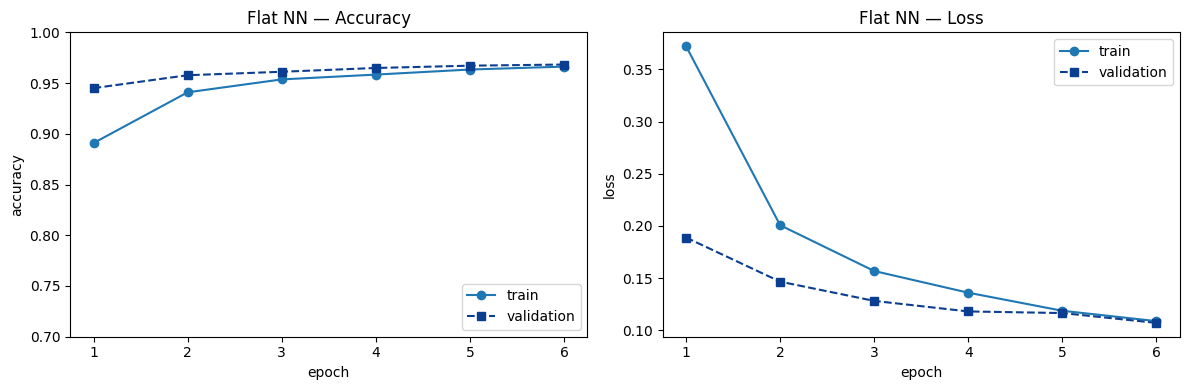

In [8]:
def plot_learning_curves(history, title_prefix=''):
    """Plots accuracy and loss vs epoch from a Keras History object, in a blue color scheme."""
    epochs_range = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy curve
    axes[0].plot(epochs_range, history.history['accuracy'],
                 color='#1f77b4', marker='o', label='train')
    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 color='#0b3d91', marker='s', linestyle='--', label='validation')
    axes[0].set_title(f'{title_prefix}Accuracy')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('accuracy')
    # Set y axis limits
    axes[0].set_ylim(0.7, 1.0)
    axes[0].legend(loc='lower right')

    # Loss curve
    axes[1].plot(epochs_range, history.history['loss'],
                 color='#1f77b4', marker='o', label='train')
    axes[1].plot(epochs_range, history.history['val_loss'],
                 color='#0b3d91', marker='s', linestyle='--', label='validation')
    axes[1].set_title(f'{title_prefix}Loss')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_flat, title_prefix='Flat NN — ')

### Evaluate on the held-out test set

The validation split only sees data during training.

The **test set** has never been used to pick hyperparameters, so its loss/accuracy are an honest estimate of generalization.

In [9]:
test_loss_flat, test_acc_flat = flat_model.evaluate(x_test, y_test, verbose=0)
print(f"Flat NN — Test loss:     {test_loss_flat:.4f}")
print(f"Flat NN — Test accuracy: {test_acc_flat:.4f}")

Flat NN — Test loss:     0.0992
Flat NN — Test accuracy: 0.9724


### Raw confusion matrix (blue color scheme)

A confusion matrix shows, for every (true class, predicted class) pair, the number of test examples that fall in that bucket. The diagonal = correct predictions; everything off-diagonal = mistakes.

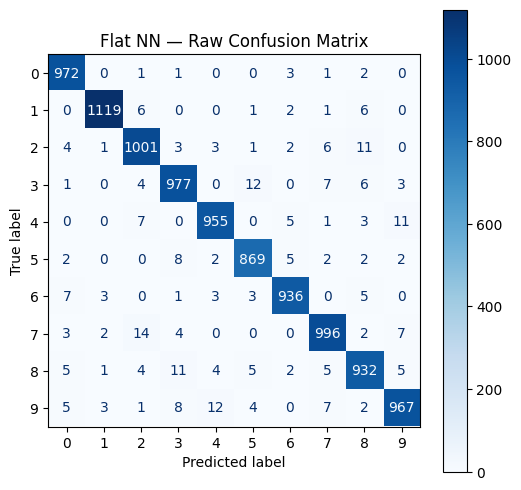

In [10]:
# Predict class indices for the whole test set
y_pred_flat = np.argmax(flat_model.predict(x_test, verbose=0), axis=1)

cm_flat = confusion_matrix(y_test, y_pred_flat)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_flat)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
ax.set_title('Flat NN — Raw Confusion Matrix')
plt.grid(False)
plt.show()

## Task 1. Normalized Confusion Matrices

The raw confusion matrix tells you *counts*.

Normalized confusion matrices rescale each row or column to sum to 1:

- **Normalized by `'true'`** (rows): entry $(i, j)$ = probability of predicting class $j$ **given that the true class is $i$**. This is the recall/efficiency view.

- **Normalized by `'pred'`** (columns): entry $(i, j)$ = probability that the true class is $i$ **given that the prediction was $j$**. This is the precision/purity view.

Produce **both** normalized confusion matrices for the Flat NN, using the **blue color scheme** (`cmap=plt.cm.Blues`). Round entries to 2 decimals for readability.

⭕️⭕️

In a short markdown cell underneath, explain in 1–3 sentences **what each of the two plots is telling you** and **which digits the Flat NN confuses most often**.

⭕️

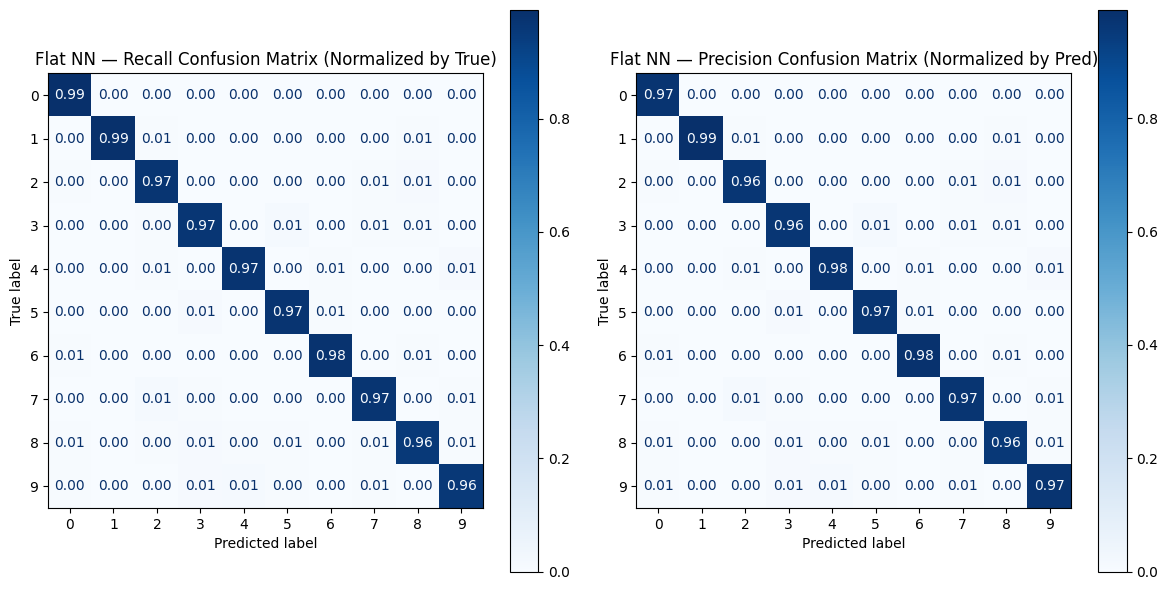

In [16]:
cm_flat = confusion_matrix(y_test, y_pred_flat)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cm_flat = confusion_matrix(y_test, y_pred_flat, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_flat)
disp.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='.2f', colorbar=True)
axes[0].set_title('Flat NN — Recall Confusion Matrix (Normalized by True)')

cm_flat = confusion_matrix(y_test, y_pred_flat, normalize='pred')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_flat)
disp.plot(cmap=plt.cm.Blues, ax=axes[1], values_format='.2f', colorbar=True)
axes[1].set_title('Flat NN — Precision Confusion Matrix (Normalized by Pred)')

plt.tight_layout()
plt.grid(False)
plt.show()

Both plots indicate that the flat neural network has a high degree of accuracy - no values along the diagonals are below 96%. Furthermore, no incorrect predictions are made particularly frequently - all the non-diagonal squares are either 0 or 0.01. The model has a hardest time with 8's and 9's, which it will sometimes call 0, 3, 4, 5, or 7.

## Task 2. Experiment to build the best flat network

Re-train the Flat NN several times while varying **one knob at a time**:

1. **Learning rate** try at least 3 values spanning at least a factor of 100 (e.g. `1e-4`, `1e-3`, `1e-2`). Use `tf.keras.optimizers.Adam(learning_rate=...)` and pass it to `model.compile(optimizer=...)`.
2. **Batch size** try at least 3 values (e.g. `16`, `64`, `256`).
3. **Number of epochs** try at least 2 meaningfully different values (e.g. `3` and `15`).
4. **Number of layers** try this network with different numbers of layers to find an optimal version of the network.

Store the training histories so you can re-plot them for later questions. Use the `plot_learning_curves` helper or write your own — keep the **blue color scheme** consistent.

⭕️⭕️

> Keep these results around — questions **Q1**, **Q3**, and **Q4** below will ask you to reason over them.

In [17]:
# TODO: write a small helper that builds a fresh flat model, compiles it with a given
# learning rate, fits it with a given batch size and number of epochs, and returns
# (history, test_loss, test_accuracy).

def train_flat(learning_rate=1e-3, batch_size=32, epochs=6):
    model = build_flat_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=['accuracy'],
    )
    history = model.fit(x_train, y_train, validation_split=0.25,
                        epochs=epochs, batch_size=batch_size, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return history, test_loss, test_acc


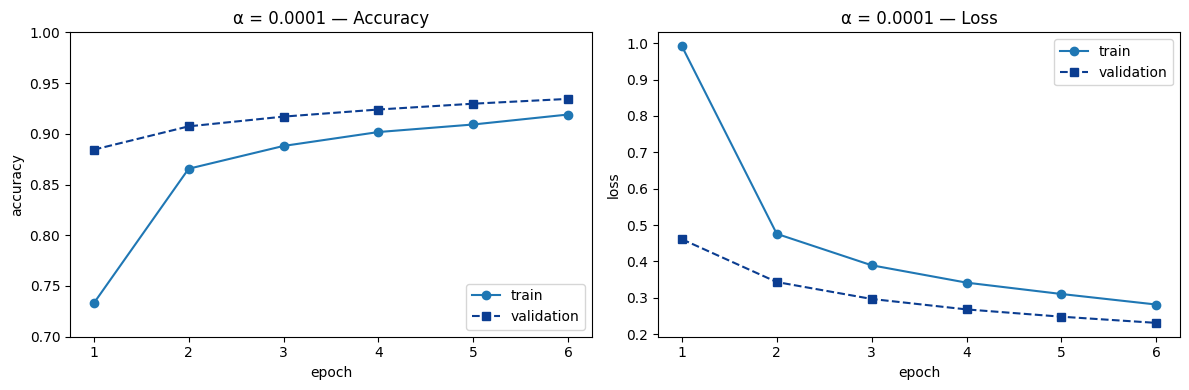

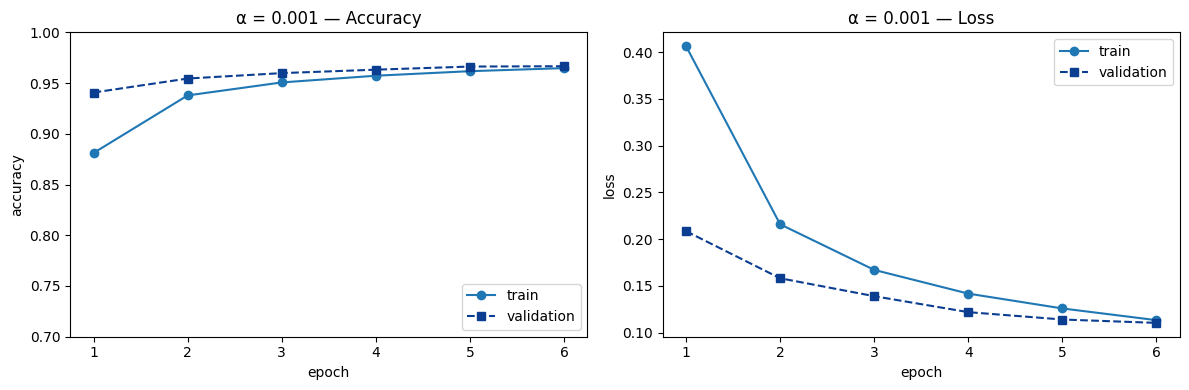

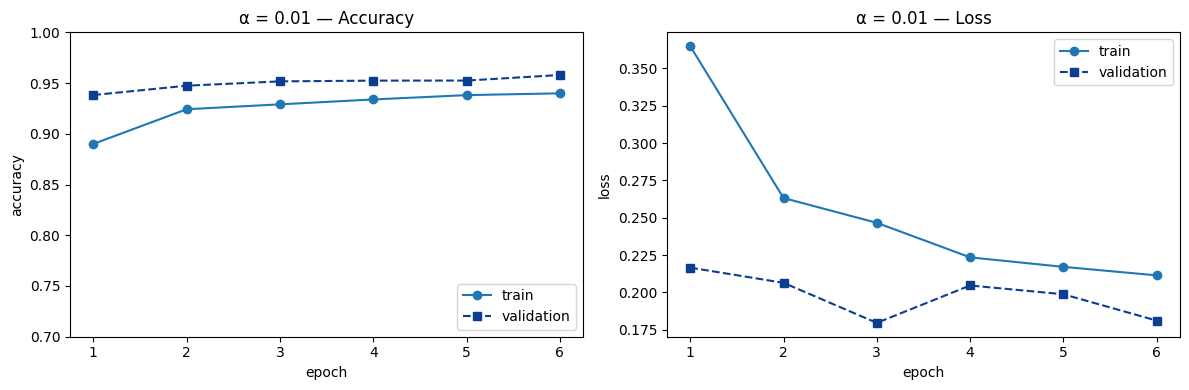

In [20]:
results_alpha_minus_4 = train_flat(learning_rate=1e-4)
plot_learning_curves(results_alpha_minus_4[0], title_prefix='α = 0.0001 — ')
results_alpha_minus_3 = train_flat(learning_rate=1e-3)
plot_learning_curves(results_alpha_minus_3[0], title_prefix='α = 0.001 — ')
results_alpha_minus_2 = train_flat(learning_rate=1e-2)
plot_learning_curves(results_alpha_minus_2[0], title_prefix='α = 0.01 — ')


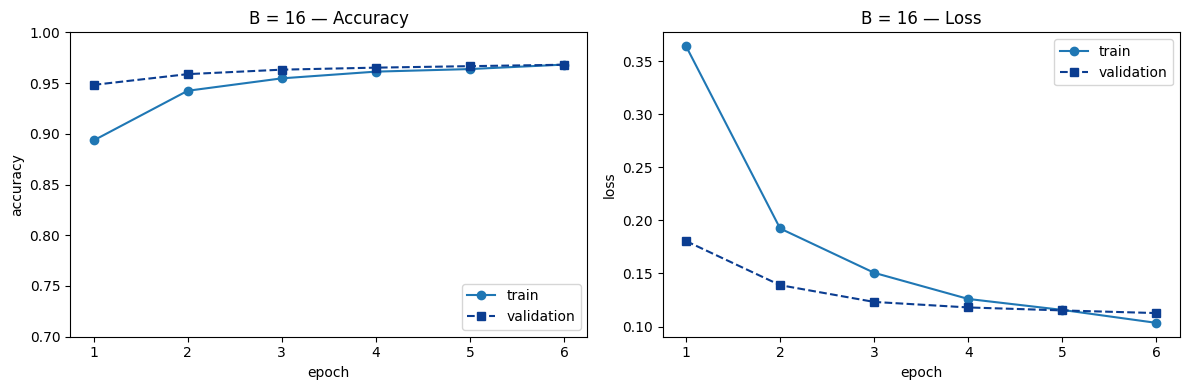

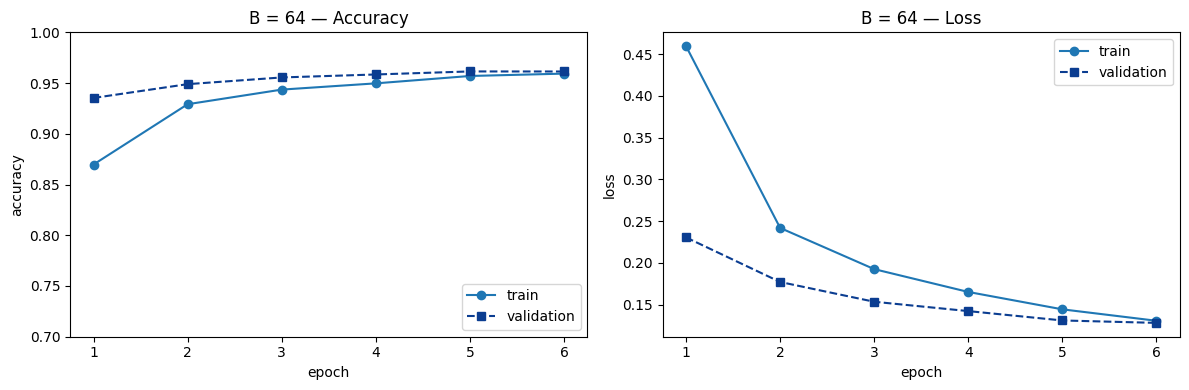

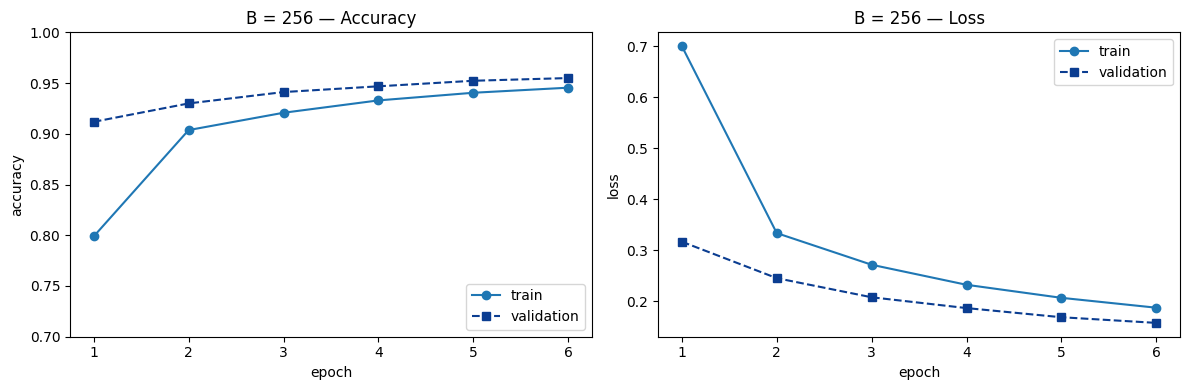

In [22]:
# TODO: run at least 3 batch sizes and plot their learning curves 16, 64, 256
results_batch_16 = train_flat(batch_size=16)
plot_learning_curves(results_batch_16[0], title_prefix='B = 16 — ')
results_batch_64 = train_flat(batch_size=64)
plot_learning_curves(results_batch_64[0], title_prefix='B = 64 — ')
results_batch_256 = train_flat(batch_size=256)
plot_learning_curves(results_batch_256[0], title_prefix='B = 256 — ')



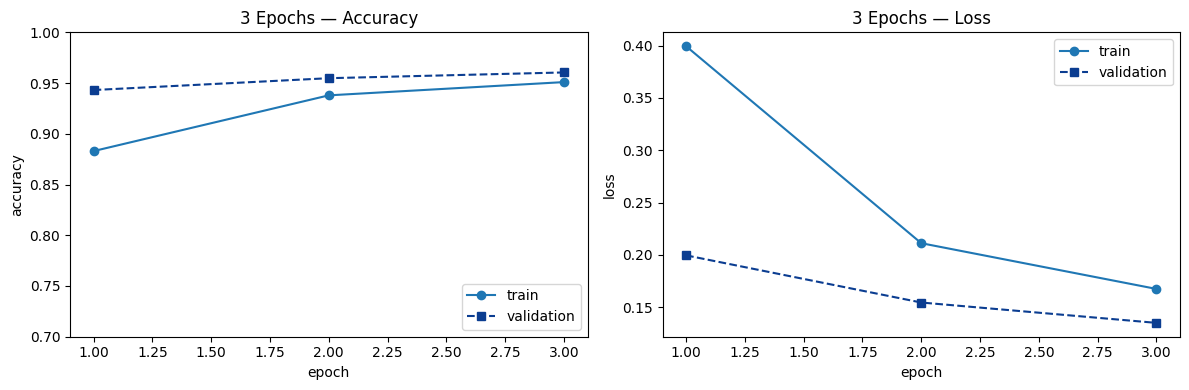

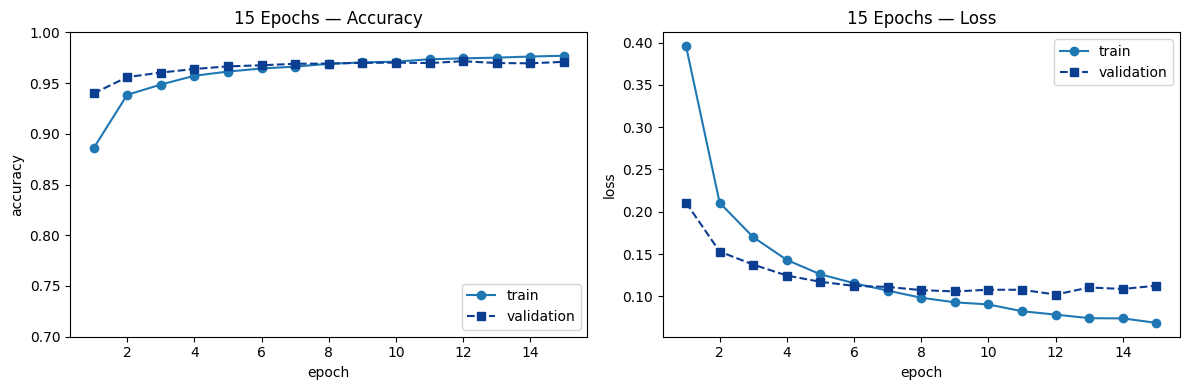

In [23]:
# TODO: run at least 2 epoch counts and plot their learning curves (e.g. 3 and 15)
results_epoch_3 = train_flat(epochs=3)
plot_learning_curves(results_epoch_3[0], title_prefix='3 Epochs — ')
results_epoch_15 = train_flat(epochs=15)
plot_learning_curves(results_epoch_15[0], title_prefix='15 Epochs — ')

## Task 3. Build your best flat network

Try any combination of the above parameters that will give you at least 95% efficiency for all categories. Train the network and produce normalized confusion matrices to show the performance.

⭕️⭕️⭕️

⭕️⭕️⭕️

In [43]:
def train_flat_model(learning_rate=1e-3, batch_size=32, epochs=6):
  '''Same as above, but returns model as the fourth element of the tuple'''
  model = build_flat_model()
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
      loss=loss_fn,
      metrics=['accuracy'],
  )
  history = model.fit(x_train, y_train, validation_split=0.25,
                      epochs=epochs, batch_size=batch_size, verbose=0)
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
  return history, test_loss, test_acc, model

def plot_learning_curves_better(results, title_prefix):
  history, test_loss, test_acc, *_ = results
  epochs_range = range(1, len(history.history['loss']) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Accuracy curve
  axes[0].plot(epochs_range, history.history['accuracy'],
                color='#1f77b4', marker='o', label='train')
  axes[0].plot(epochs_range, history.history['val_accuracy'],
                color='#0b3d91', marker='s', linestyle='--', label='validation')
  axes[0].set_title(f'{title_prefix}Accuracy ({test_acc:.2f})')
  axes[0].set_xlabel('epoch')
  axes[0].set_ylabel('accuracy')
  # Set y axis limits
  axes[0].set_ylim(0.7, 1.0)
  axes[0].legend(loc='lower right')

  # Loss curve
  axes[1].plot(epochs_range, history.history['loss'],
                color='#1f77b4', marker='o', label='train')
  axes[1].plot(epochs_range, history.history['val_loss'],
                color='#0b3d91', marker='s', linestyle='--', label='validation')
  axes[1].set_title(f'{title_prefix}Loss ({test_loss:.2f})')
  axes[1].set_xlabel('epoch')
  axes[1].set_ylabel('loss')
  axes[1].legend(loc='upper right')

  plt.tight_layout()
  plt.show()


def normalized_confusion_matrices(model, title_prefix):
  y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
  cm = confusion_matrix(y_test, y_pred)

  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  cm = confusion_matrix(y_test, y_pred, normalize='true')
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='.2f', colorbar=True)
  axes[0].set_title(f'{title_prefix}Efficiency Confusion Matrix (Normalized by True)')

  cm = confusion_matrix(y_test, y_pred, normalize='pred')
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=plt.cm.Blues, ax=axes[1], values_format='.2f', colorbar=True)
  axes[1].set_title(f'{title_prefix}Purity Confusion Matrix (Normalized by Pred)')

  plt.tight_layout()
  plt.grid(False)
  plt.show()

In [34]:
# TODO: Implement your best version of the flat network

best_results = train_flat_model(learning_rate=1e-3, batch_size=16, epochs=6)



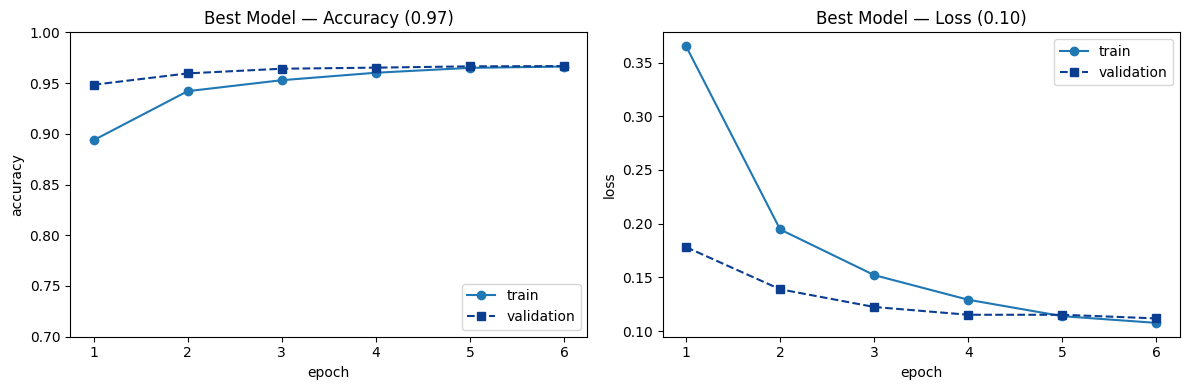

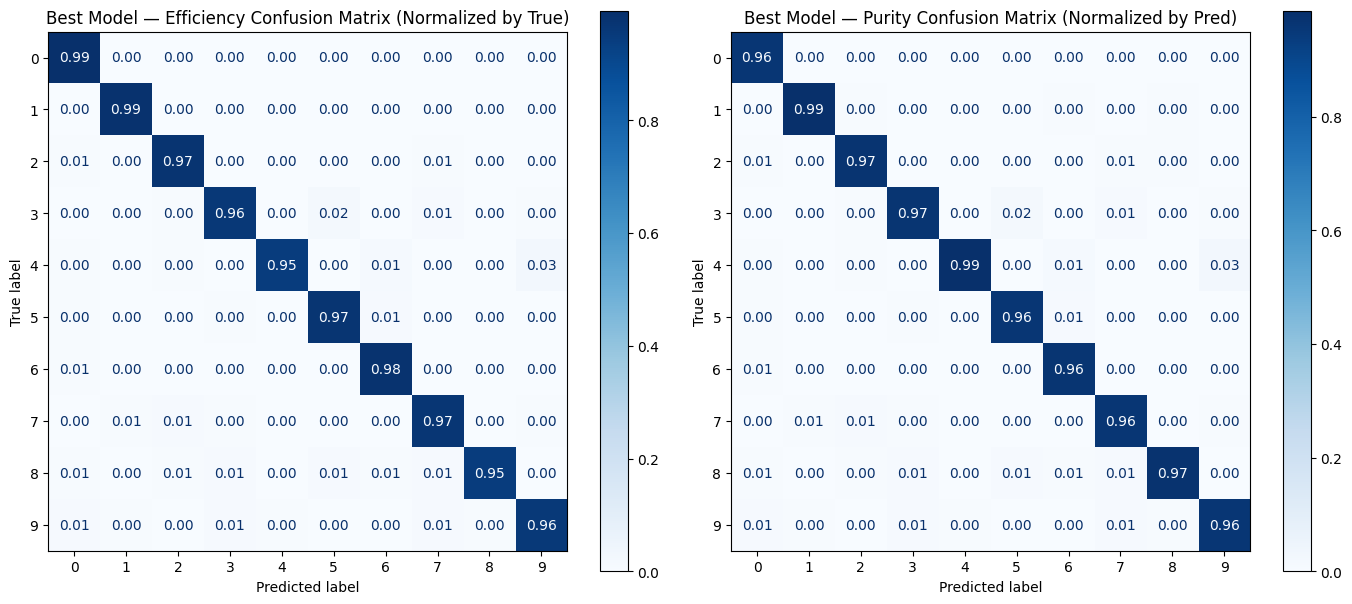

In [44]:
# TODO: Create loss, accuracy, and confusion matrix plots
prefix = 'Best Model — '
plot_learning_curves_better(best_results, title_prefix=prefix)
model = best_results[3]
normalized_confusion_matrices(model, prefix)


This ended up training worse than the initial model, even though I thought I was using the same exact parameters... Is it just randomization?

## Task 4. Build a Convolutional Neural Network

Convolutional layers exploit the spatial structure that `Flatten` threw away. Implement a small CNN with **at least** the following structure:

- Input reshaped to shape `(28, 28, 1)` (a single grayscale channel).
- At least **two** `Conv2D` layers (32 then 64 convolutions, 3×3 kernels, `relu` activation).
- At least **one** `MaxPooling2D` layer.
- A `Flatten` (only at the end, *after* the convolutions).
- A `Dense` hidden layer with dropout.
- A final `Dense(10)` + `Softmax` for classification.

Compile and train it on the **full, unaltered** MNIST training set. Use `validation_split=0.25` and the same loss function.

⭕️⭕️⭕️⭕️

In [45]:
# TODO: build a CNN. You may want to use tf.keras.layers.Reshape((28, 28, 1)) at the top.

def build_cnn_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input((28, 28)),
        tf.keras.layers.Reshape((28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10),
        tf.keras.layers.Softmax(),
    ])
    return model

cnn_model = build_cnn_model()
cnn_model.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_17 (Softmax)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,146 (1.97 MB)

 Trainable params: 515,146 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# TODO: compile and train the CNN. Save the history to history_cnn.
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_cnn = cnn_model.fit(x_train, y_train, validation_split=0.25, epochs=6, batch_size=32)


Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.9467 - loss: 0.1768 - val_accuracy: 0.9781 - val_loss: 0.0710
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9801 - loss: 0.0632 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9871 - loss: 0.0402 - val_accuracy: 0.9857 - val_loss: 0.0528
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.9887 - loss: 0.0335 - val_accuracy: 0.9885 - val_loss: 0.0445
Epoch 5/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.9913 - loss: 0.0257 - val_accuracy: 0.9866 - val_loss: 0.0462
Epoch 6/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.9890 - val_loss: 0.0492


## Task 5. CNN Evaluation

For the CNN you trained above, produce:

1. The **learning curves** (accuracy and loss).

⭕️

2. The **raw confusion matrix** on the test set in the blue color scheme.

⭕️

3. Both **normalized confusion matrices** (`'true'` and `'pred'`) on the test set in the blue color scheme.

⭕️

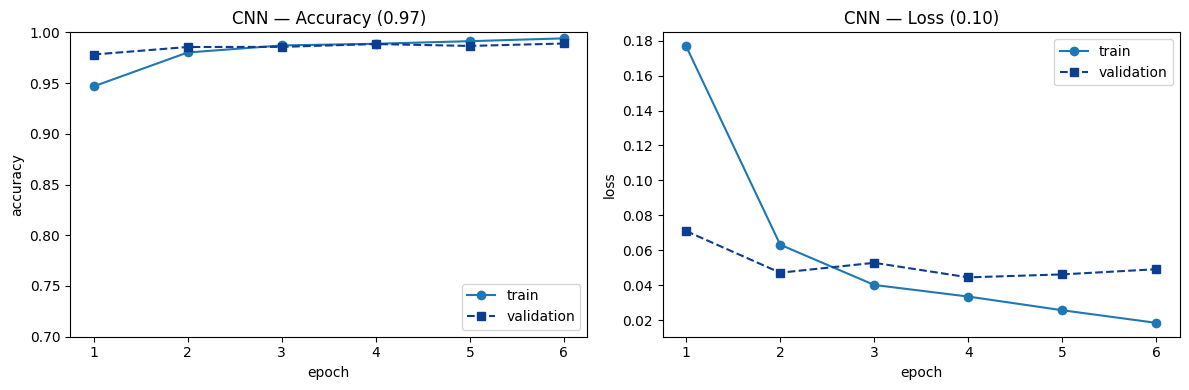

In [48]:
cnn_results = [history_cnn, *model.evaluate(x_test, y_test, verbose=0)]
plot_learning_curves_better(cnn_results, 'CNN — ')


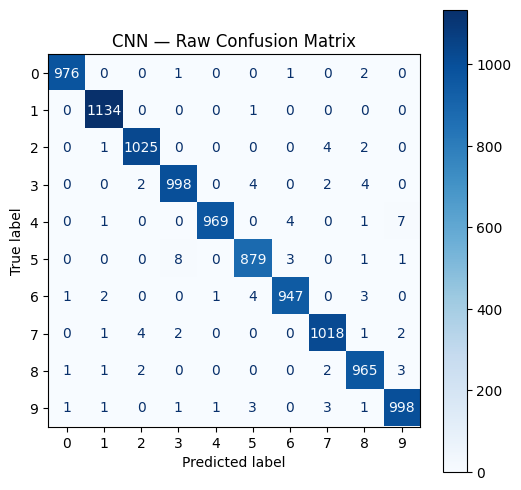

In [49]:
# Predict class indices for the whole test set
y_pred_cnn = np.argmax(cnn_model.predict(x_test, verbose=0), axis=1)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
ax.set_title('CNN — Raw Confusion Matrix')
plt.grid(False)
plt.show()

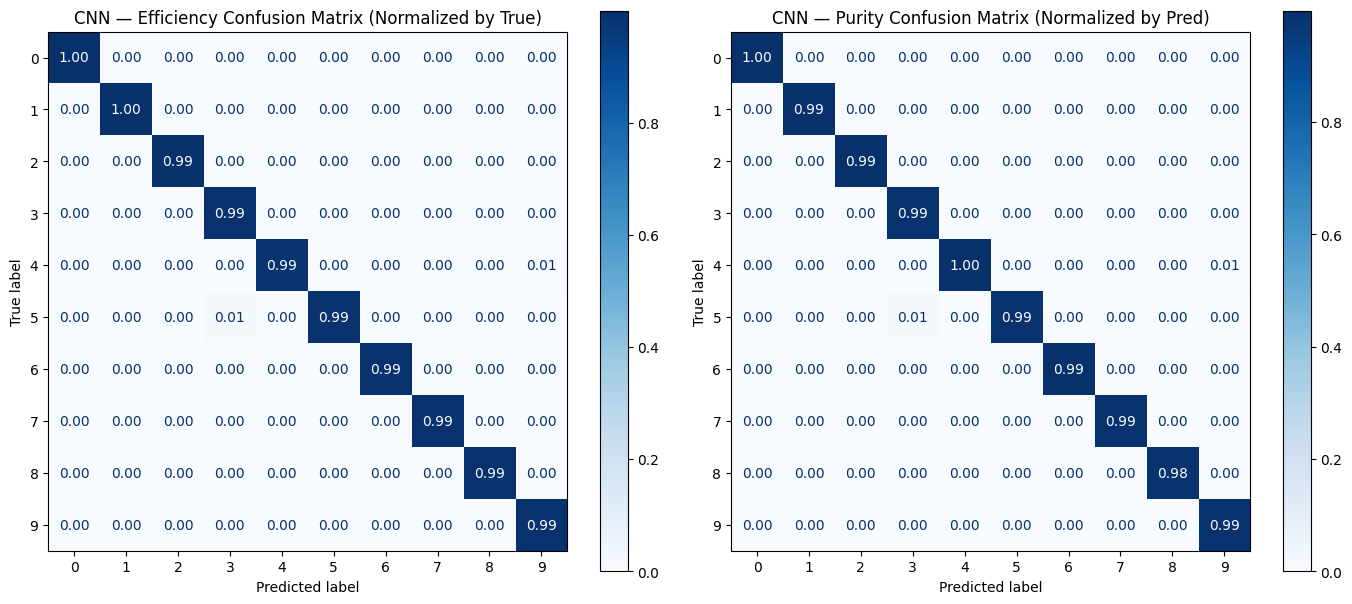

In [50]:
# TODO: plot both normalized CNN confusion matrices
normalized_confusion_matrices(cnn_model, 'CNN — ')


## Questions

Answer each question in its own markdown cell. Plots that support your answer should go into the code cell immediately above the answer. Be concrete — cite specific numbers and refer to specific plots.

### Q1. What do you observe if you vary the learning rate, batch size, and number of epochs?

Using the experiments from **Task 2**, describe in 3–6 sentences what happens to:
- the *shape* of the learning curves,
- the *final* train vs. validation accuracy, and
- the *stability* of training.

Name at least one setting that is clearly **too small**, one that is **too large**, and one that is **about right**.

⭕️⭕️

Modifying the Learning Rate α
- if the learning rate is too small, the learning curves converge very slowly, but if it is too large, they will either plateau too quickly or be unstable.
- the final train vs. validation accuracy is highest when the learning rate is somehere in the middle - not too high, and not too low. The difference between the training and validation accuracy is lowest when the learning rate is in this "Goldilocks zone" too.
- the training becomes unstable if the learning rate is too high. This is seen in the loss function when learning rate is equal to 0.01. The Validation loss jumps up and down.

Modifying the Batch Size B
- It seems like the model learns quickest with a smaller batch size, as seen by comparing how quickly it plateaus in the three graphs.
- the final train and validation accuracy are closest together when the batch size is low
- doesn't seem to affect model stability

Modifying the Number of Epochs
- Too few epochs and the model doesn't get enough time to "learn"
- Too many epochs and the model tries to improve upon the best it can do, leading to instability and oscillation
- Too many epochs and the model can begin to overfit to the test data and fail to generalize to the population, meaning that it will perform better on the training data than on the test data, as seen in the Loss curve for 15 epochs.

### Q2. Why is the performance the same/different between the CNN and the original Flat-input NN?

Compare the test accuracies *and* the normalized confusion matrices of the two models. In 2–5 sentences explain the differences and why performance is different.

⭕️⭕️

In both models, accuracy and loss were 0.97 and 0.10 respectively. The flat model showed signs of overfitting when comparing the loss curves for training and validation. The CNN did not show the same signs of overfitting.

The flat model tended to call a lot of 4's 9's (0.03 in 4-true, 9-pred). The CNN also had this problem, but to a much smaller extent (only 0.01 in the same spot).

### Q3. What is the most efficient algorithm configuration if you want to achieve global 95% accuracy as fast as possible?

"Fast" here means **wall-clock training time** to cross 90% **validation** accuracy for the first time. Use the runs you already have (and add new ones if needed). State:

- the winning configuration (model type, learning rate, batch size, epochs),
- the approximate wall time it needed to cross 90%,
- why you think it won (fewer parameters? larger effective step? etc.).

⭕️⭕️⭕️

🥇 It only took 42 seconds to train the very first flat model in the notebook, which had a 94% accuracy by the end of the second epoch, only 14 s in.
- Flat model
- 0.001 Learning Rate (default for Adam optimizer)
- 16 Batch Size
- 6 Epochs

🥈 The CNN took 5 minutes to complete training, and it took 48 seconds to complete the first epoch, after which the accuracy was 94%.

The flat model had 50,890 parameters, while the CNN had 515,146 parameters, over ten times as many. So it makes sense that the flat model took less time to train.

### Q4. What algorithm configuration gave you the best results across categories?

Define what you mean by **best results** (e.g. "highest test accuracy", "best worst-class recall", "best accuracy / training-time ratio", "smallest overfitting gap", etc.) and justify your choice with **at least 2 plots** that compare your winner to other variants.

⭕️⭕️⭕️

> The model with the best results was the CNN. Though its final accuracy and loss were the same as the flat model, it had a smaller overfitting gap. Also, its confusion matrix showed higher accuracy overall.

Why do you think this was the best network for this task?

⭕️⭕️

> The only downside of the CNN is it takes more time and space to train and run. But the time difference is less than five minutes, and the space is negligible since it's all running on Google's cloud computers.

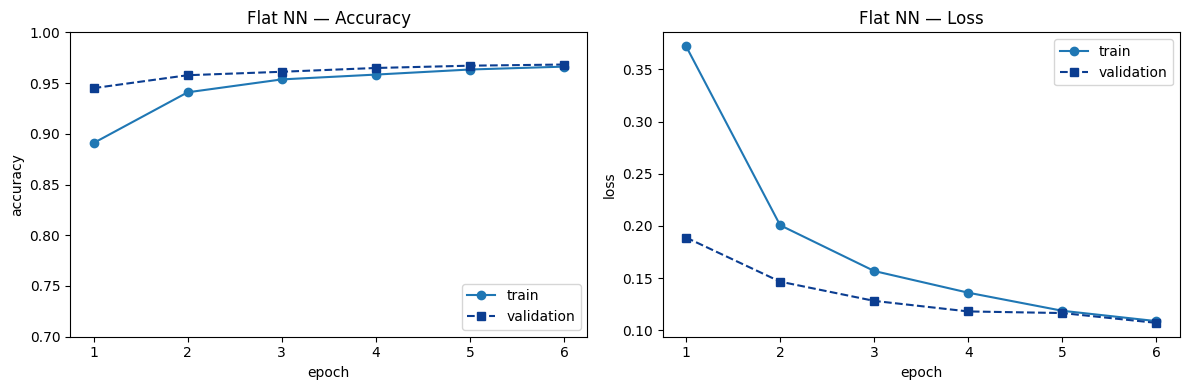

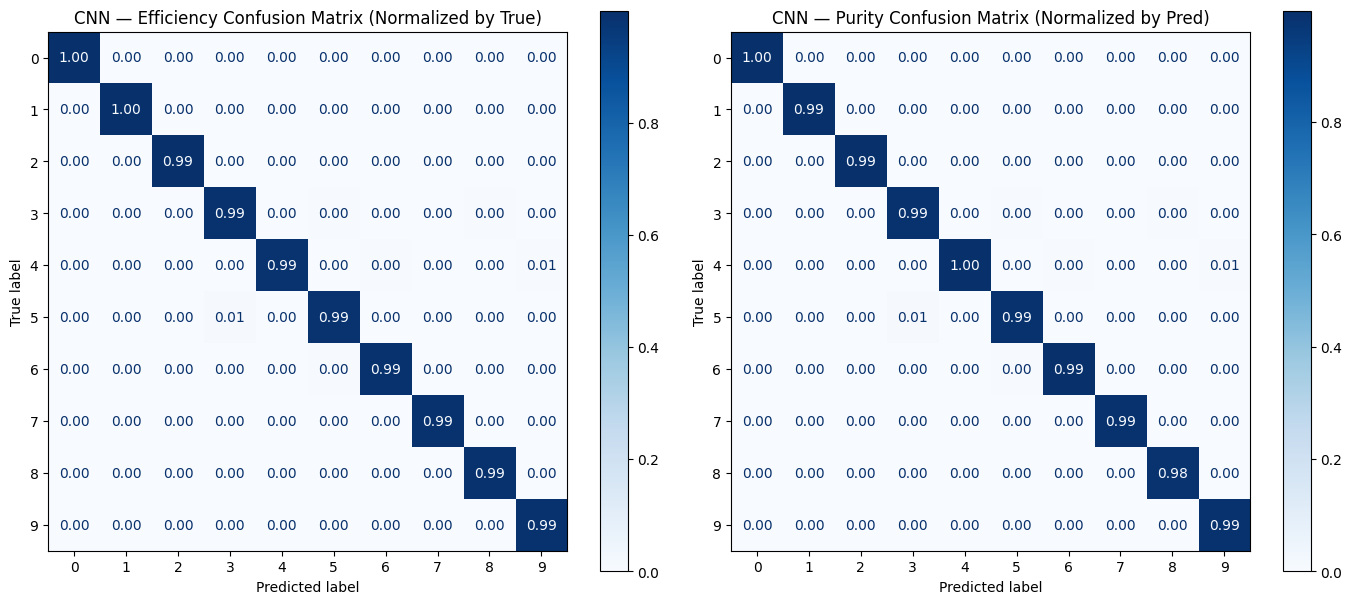

### Q5. At least Five plots characterizing your Q4 winner (EXTRA CREDIT APPLICABLE TO OTHER ASSIGNMENTS)

Create **at least 5 plots** with different metrics that show different aspects of the performance of the training and the quality of the results for your Q4 configuration. For each one, write **one sentence** stating what it shows.

Suggestions (pick any 5, or invent your own):
- per-class precision / recall / bar charts,
- histogram of predicted probabilities for correctly- vs. incorrectly-classified examples,
- a gallery of misclassified test images with predicted vs. true labels,
- ROC or precision-recall curve for one-vs-rest for a few classes,
- accuracy vs. training time,
- efficiency / purity comparisons to other networks

**You need at least 5 to receive extra credit. You can earn up to 10 points of extra credit.**

Your plots must be:
- Clearly labeled (title, axes, legends)
- Correctly implemented
- Must have a 1-sentence caption that explains them
- They must all be sufficiently different from one-another (aka, one efficiency comparison for each class would only be one extra point)

⭕️⭕️⭕️⭕️⭕️

⭕️⭕️⭕️⭕️⭕️

In [ ]:
# TODO: Plot 1 + what it shows: <one sentence>


In [ ]:
# TODO: Plot 2 + what it shows: <one sentence>


In [ ]:
# TODO: Plot 3 + what it shows: <one sentence>


In [ ]:
# TODO: Plot 4 + what it shows: <one sentence>


In [ ]:
# TODO: Plot 5 + what it shows: <one sentence>
